# Etapa 2 - EDA e preparacao inicial

Nesta etapa, o objetivo e preparar os dados do Tracebase para um problema de classificacao de eletrodomesticos com base no padrao de consumo eletrico.

Para manter o projeto coerente com o contexto atual de consumo residencial, vamos trabalhar apenas com classes de aparelhos que fazem mais sentido para a analise.

## 1. Importar bibliotecas

In [28]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

## 2. Verificar o dataset

Primeiro, vamos confirmar se a pasta `tracebase/complete` foi encontrada e quantos arquivos CSV existem nela.

In [29]:
DATASET_PATH = Path("tracebase/complete")

arquivos_csv = sorted(DATASET_PATH.rglob("*.csv"))

print("Total de arquivos:", len(arquivos_csv))
print("Primeiros arquivos:", arquivos_csv[:5])

Total de arquivos: 1836
Primeiros arquivos: [WindowsPath('tracebase/complete/Alarmclock/dev_59AC89_2011.09.01.csv'), WindowsPath('tracebase/complete/Alarmclock/dev_59AC89_2011.09.02.csv'), WindowsPath('tracebase/complete/Alarmclock/dev_59AC89_2011.09.03.csv'), WindowsPath('tracebase/complete/Alarmclock/dev_59AC89_2011.09.04.csv'), WindowsPath('tracebase/complete/Alarmclock/dev_59AC89_2011.09.05.csv')]


## 3. Ler um arquivo de exemplo

Antes de trabalhar com todo o conjunto, vamos abrir um CSV para entender sua estrutura.

In [30]:
colunas = ["timestamp", "potencia_1s", "potencia_8s"]

df_exemplo = pd.read_csv(
    arquivos_csv[0],
    sep=";",
    header=None,
    names=colunas
)

df_exemplo.head()

,timestamp,potencia_1s,potencia_8s
0,01/09/2011 00:00:02,0,0
1,01/09/2011 00:00:04,2,0
2,01/09/2011 00:00:07,2,0
3,01/09/2011 00:00:09,2,0
4,01/09/2011 00:00:12,2,0


## 4. Verificar os tipos de eletrodomesticos

Cada pasta dentro de `complete` representa uma classe de eletrodomestico.

In [31]:
tipos = sorted({arquivo.parent.name for arquivo in arquivos_csv})

print("Quantidade de tipos:", len(tipos))
print(tipos)

Quantidade de tipos: 43
['Alarmclock', 'Amplifier', 'BeanToCupCoffeemaker', 'Breadcutter', 'CdPlayer', 'Charger-PSP', 'Charger-Smartphone', 'Coffeemaker', 'Cookingstove', 'DigitalTvReceiver', 'Dishwasher', 'DvdPlayer', 'EthernetSwitch', 'Freezer', 'Iron', 'Lamp', 'LaundryDryer', 'MicrowaveOven', 'Monitor-CRT', 'Monitor-TFT', 'Multimediacenter', 'PC-Desktop', 'PC-Laptop', 'Playstation3', 'Printer', 'Projector', 'Refrigerator', 'RemoteDesktop', 'Router', 'SolarThermalSystem', 'Subwoofer', 'TV-CRT', 'TV-LCD', 'Toaster', 'USBHarddrive', 'USBHub', 'VacuumCleaner', 'VideoProjector', 'Washingmachine', 'WaterBoiler', 'WaterFountain', 'WaterKettle', 'XmasLights']


## 5. Escolher as classes mais coerentes para o projeto

Nem todas as classes do Tracebase fazem sentido para o problema proposto. Aqui vamos manter apenas aparelhos mais relevantes para uma analise atual de consumo residencial.

In [32]:
classes_escolhidas = [
    "Refrigerator",
    "MicrowaveOven",
    "Washingmachine",
    "Dishwasher",
    "WaterKettle",
    "Lamp",
    "TV-LCD",
    "PC-Desktop",
    "PC-Laptop",
    "Coffeemaker"
]

print(classes_escolhidas)

['Refrigerator', 'MicrowaveOven', 'Washingmachine', 'Dishwasher', 'WaterKettle', 'Lamp', 'TV-LCD', 'PC-Desktop', 'PC-Laptop', 'Coffeemaker']


## 6. Criar a base de features

Agora, cada arquivo CSV sera transformado em uma linha da base final. Para cada arquivo, vamos calcular medidas simples de consumo.

In [33]:
dados = []

for arquivo in arquivos_csv:
    eletrodomestico = arquivo.parent.name

    if eletrodomestico not in classes_escolhidas:
        continue

    df_temp = pd.read_csv(
        arquivo,
        sep=";",
        header=None,
        names=colunas
    )

    dados.append({
        "eletrodomestico": eletrodomestico,
        "arquivo": arquivo.name,
        "media_1s": df_temp["potencia_1s"].mean(),
        "max_1s": df_temp["potencia_1s"].max(),
        "min_1s": df_temp["potencia_1s"].min(),
        "desvio_1s": df_temp["potencia_1s"].std(),
        "media_8s": df_temp["potencia_8s"].mean(),
        "max_8s": df_temp["potencia_8s"].max(),
        "min_8s": df_temp["potencia_8s"].min(),
        "desvio_8s": df_temp["potencia_8s"].std()
    })

df_features = pd.DataFrame(dados)
df_features.head()

,eletrodomestico,arquivo,media_1s,max_1s,min_1s,desvio_1s,media_8s,max_8s,min_8s,desvio_8s
0,Coffeemaker,dev_735E9D_2012.05.15.csv,13.899007,1305,2,88.708874,13.406904,1239,2,66.351628
1,Coffeemaker,dev_735E9D_2012.05.16.csv,10.644890,1303,2,75.224542,9.760772,1209,2,56.887912
2,Coffeemaker,dev_735E9D_2012.05.19.csv,15.078373,1343,2,93.679758,14.258345,1230,2,67.312265
3,Coffeemaker,dev_735E9D_2012.05.21.csv,12.875879,1311,2,86.478882,11.226001,1239,2,59.615865
4,Coffeemaker,dev_735E9D_2012.05.23.csv,9.900743,1322,2,73.421394,8.968545,1190,2,54.253573


## 7. Verificar o tamanho da base

Depois do filtro, vamos conferir quantas linhas e colunas ficaram na base.

In [34]:
df_features.shape

(1037, 10)

## 8. Analisar a distribuicao das classes

Aqui verificamos quantos arquivos existem para cada eletrodomestico escolhido.

In [35]:
contagem_classes = df_features["eletrodomestico"].value_counts()
contagem_classes

eletrodomestico
Refrigerator      206
PC-Desktop        151
WaterKettle       134
TV-LCD            119
Lamp               86
Coffeemaker        82
Dishwasher         76
PC-Laptop          67
MicrowaveOven      60
Washingmachine     56
Name: count, dtype: int64

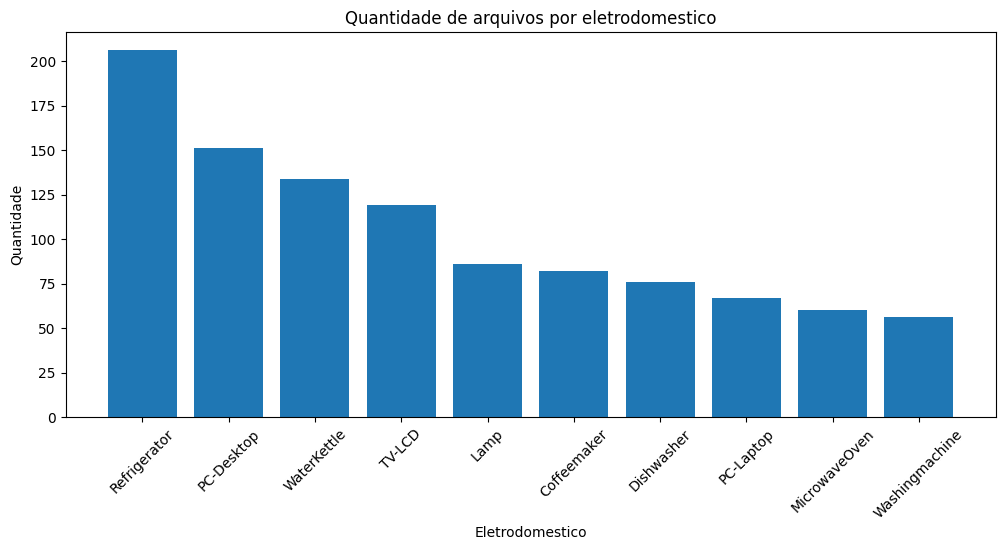

In [36]:
plt.figure(figsize=(12, 5))
plt.bar(contagem_classes.index, contagem_classes.values)
plt.title("Quantidade de arquivos por eletrodomestico")
plt.xlabel("Eletrodomestico")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.show()

## 9. Ver estatisticas gerais das features

Essa etapa ajuda a entender os valores medios, minimos, maximos e a variacao das features numericas.

In [37]:
df_features.describe()

,media_1s,max_1s,min_1s,desvio_1s,media_8s,max_8s,min_8s,desvio_8s
count,1037.000000,1037.000000,1037.000000,1037.000000,1037.000000,1037.00000,1037.000000,1037.000000
mean,29.379727,962.769527,5.537126,83.286728,28.909516,820.98650,5.202507,81.313174
std,28.192767,899.201326,18.095303,95.838699,28.089515,914.48277,17.688845,95.807431
min,0.000742,2.000000,0.000000,0.038520,0.000000,0.00000,0.000000,0.000000
25%,7.262756,111.000000,0.000000,21.875015,7.096684,107.00000,0.000000,21.603777
50%,18.537889,862.000000,0.000000,51.445101,18.428930,237.00000,0.000000,49.550240
75%,41.056747,1668.000000,0.000000,90.585348,40.842252,1627.00000,0.000000,86.185062
max,128.524817,3058.000000,98.000000,534.727946,127.704701,3017.00000,100.000000,533.875982


## 10. Verificar valores ausentes

Antes de finalizar a preparacao, vamos verificar se existem valores ausentes na base de features.

In [38]:
df_features.isnull().sum()

eletrodomestico    0
arquivo            0
media_1s           0
max_1s             0
min_1s             0
desvio_1s          0
media_8s           0
max_8s             0
min_8s             0
desvio_8s          0
dtype: int64

## 11. Separar X e y

No final da Etapa 2, a base precisa ficar pronta para a futura modelagem.

In [39]:
X = df_features.drop(columns=["eletrodomestico", "arquivo"])
y = df_features["eletrodomestico"]

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (1037, 8)
Shape de y: (1037,)


## 12. Salvar a base processada

A base final sera salva para ser usada na proxima etapa do projeto, quando os modelos de classificacao forem treinados.

In [40]:
saida = Path("data/processed")
saida.mkdir(parents=True, exist_ok=True)

df_features.to_csv(saida / "tracebase_complete_features.csv", index=False)

print("Arquivo salvo em:", saida / "tracebase_complete_features.csv")

Arquivo salvo em: data\processed\tracebase_complete_features.csv


## 13. Conclusao da preparacao

Apos o filtro das classes, a base ficou com 1037 registros e 10 tipos de eletrodomesticos. Cada registro representa um arquivo de medicao do Tracebase, transformado em features numericas de consumo eletrico.

As classes escolhidas representam aparelhos mais relevantes para uma analise atual de consumo residencial. A base final possui o target `eletrodomestico` e as variaveis preditoras relacionadas a media, maximo, minimo e desvio padrao da potencia eletrica.

Com isso, os dados estao preparados para a proxima etapa do projeto: treinamento e avaliacao de modelos de classificacao.